# Demo 1 — End-to-End Enterprise RAG Pipeline

**Unit 3: Architecture, GenAI Patterns & Risk**

This notebook builds a working RAG pipeline that mirrors the reference architecture from Module 1:

`Data Sources → Ingestion & Chunking → Embedding + Vector Store → Retrieval (+ Hybrid + Re-rank) → Orchestration → Generation → Evaluation`

**What you'll do:**
1. Index a small sample enterprise knowledge base (insurance policy excerpts).
2. Run **naive RAG** (vector-only retrieve-then-read).
3. Upgrade to **hybrid search** (vector + BM25 keyword).
4. Add a lightweight **re-ranking** step.
5. Generate a grounded answer with **Claude**, with citations.
6. Run a simple **faithfulness check** (LLM-as-judge) — the RAG evaluation pattern from Module 1.

> **Before you run this:** get an Anthropic API key from console.anthropic.com and paste it when prompted in the cell below (or set it as a Colab secret named `ANTHROPIC_API_KEY`). Nothing else needs configuring — this runs entirely in Colab's free tier.


In [1]:
# 1. Install dependencies (Colab-friendly)
!pip install -q anthropic sentence-transformers faiss-cpu rank_bm25


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 31.9 MB/s eta 0:00:00


In [2]:
# 2. Set up your Anthropic API key
import os
import getpass

try:
    from google.colab import userdata
    api_key = userdata.get('OpenAI_Key')
except Exception:
    api_key = None

if not api_key:
    api_key = getpass.getpass("Enter your OpenAI API key: ")

os.environ["OpenAI_Key"] = api_key
print("API key configured.")


API key configured.


## 2. Sample Enterprise Knowledge Base

A small set of insurance-policy-style documents, already split into structure-aware chunks
(by clause), each carrying metadata — exactly the pattern from the "Ingestion & Chunking
Strategy" slide in Module 1. In a real system, this step would be a nightly ETL job pulling
from a document store.


In [3]:
documents = [
    {
        "id": "POL-AUTO-001",
        "text": "Auto Policy, Section 4.2 (Collision Coverage): The Company will pay for direct "
                "and accidental physical loss to your covered auto caused by collision, subject to "
                "a $500 deductible per occurrence. Coverage applies regardless of fault.",
        "source": "Auto Policy Booklet", "effective_date": "2024-01-01",
    },
    {
        "id": "POL-AUTO-002",
        "text": "Auto Policy, Section 4.5 (Rental Reimbursement): If your covered auto is out of "
                "service due to a covered collision or comprehensive loss, the Company will "
                "reimburse rental costs up to $40/day for a maximum of 30 days.",
        "source": "Auto Policy Booklet", "effective_date": "2024-01-01",
    },
    {
        "id": "POL-HOME-010",
        "text": "Homeowners Policy, Section 3.1 (Dwelling Coverage): The Company will pay to repair "
                "or replace damage to the dwelling structure caused by a covered peril, up to the "
                "policy limit shown on the declarations page.",
        "source": "Homeowners Policy Booklet", "effective_date": "2024-03-15",
    },
    {
        "id": "POL-HOME-014",
        "text": "Homeowners Policy, Section 3.6 (Water Damage Exclusion): Damage caused by flood, "
                "surface water, or sewer backup is excluded from standard coverage. Separate flood "
                "insurance must be purchased to cover these perils.",
        "source": "Homeowners Policy Booklet", "effective_date": "2024-03-15",
    },
    {
        "id": "POL-CLAIMS-003",
        "text": "Claims Handling Guideline 3: All collision claims over $10,000 must be routed to "
                "a Senior Claims Adjuster for review before settlement is authorized. Claims under "
                "$10,000 may be settled by a standard adjuster.",
        "source": "Claims Handling Guidelines", "effective_date": "2024-06-01",
    },
    {
        "id": "POL-CLAIMS-007",
        "text": "Claims Handling Guideline 7: Any claim involving a suspected total loss (repair cost "
                "exceeds 75% of actual cash value) must be escalated to the Total Loss unit within "
                "2 business days of the initial estimate.",
        "source": "Claims Handling Guidelines", "effective_date": "2024-06-01",
    },
]

print(f"Loaded {len(documents)} chunks from {len(set(d['source'] for d in documents))} source documents.")


Loaded 6 chunks from 3 source documents.


## 3. Embed & Index — the "Embedding + Vector Store" Layer

We embed every chunk with a general-purpose sentence-transformer model and build a FAISS
index — the smallest viable version of the vector-store layer from the reference
architecture. In production you would swap FAISS for pgvector, Pinecone, Chroma, etc.
(see the Module 1 "Vector Database Options" slide) without changing anything downstream.


In [4]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

texts = [d["text"] for d in documents]
embeddings = embedder.encode(texts, normalize_embeddings=True)

dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)  # inner product on normalized vectors = cosine similarity
index.add(np.array(embeddings, dtype="float32"))

print(f"Indexed {index.ntotal} chunks, dimension {dim}.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Indexed 6 chunks, dimension 384.


## 4. Naive RAG — Retrieve-Then-Read

This is the 5-step pattern from Module 1: **embed query → retrieve top-k → stuff into
prompt → generate**. Run it once so you can feel exactly where it can fall short before we
upgrade it.


In [5]:
def vector_search(query, k=3):
    q_emb = embedder.encode([query], normalize_embeddings=True)
    scores, idxs = index.search(np.array(q_emb, dtype="float32"), k)
    return [(documents[i], float(scores[0][rank])) for rank, i in enumerate(idxs[0])]

def naive_rag_retrieve(query, k=3):
    results = vector_search(query, k=k)
    return [doc for doc, score in results]

# Try it
sample_query = "How much does the company pay for a rental car after a collision?"
for doc, score in vector_search(sample_query):
    print(f"[{score:.3f}] {doc['id']}: {doc['text'][:90]}...")


[0.647] POL-AUTO-002: Auto Policy, Section 4.5 (Rental Reimbursement): If your covered auto is out of service du...
[0.617] POL-AUTO-001: Auto Policy, Section 4.2 (Collision Coverage): The Company will pay for direct and acciden...
[0.488] POL-CLAIMS-003: Claims Handling Guideline 3: All collision claims over $10,000 must be routed to a Senior ...


## 5. Hybrid Search — Vector + Keyword (BM25)

Pure vector search can miss exact identifiers (policy section numbers, claim thresholds
like "$10,000"). We add BM25 keyword scoring and fuse it with the vector score — the
"Hybrid Search & Re-ranking" pattern from Module 1.


In [6]:
from rank_bm25 import BM25Okapi

tokenized_corpus = [d["text"].lower().split() for d in documents]
bm25 = BM25Okapi(tokenized_corpus)

def hybrid_search(query, k=3, vector_weight=0.6):
    # Vector scores over the full corpus
    q_emb = embedder.encode([query], normalize_embeddings=True)
    vec_scores = (np.array(embeddings, dtype='float32') @ q_emb[0])

    # BM25 keyword scores over the full corpus
    bm25_scores = np.array(bm25.get_scores(query.lower().split()))
    if bm25_scores.max() > 0:
        bm25_scores = bm25_scores / bm25_scores.max()  # normalize to 0-1

    fused = vector_weight * vec_scores + (1 - vector_weight) * bm25_scores
    top_idx = np.argsort(-fused)[:k]
    return [(documents[i], float(fused[i])) for i in top_idx]

# Compare: an exact-number query where keyword matching should help
exact_query = "What is the threshold for escalating a claim to a Senior Claims Adjuster?"
print("-- Vector-only --")
for doc, score in vector_search(exact_query):
    print(f"[{score:.3f}] {doc['id']}")
print("\n-- Hybrid (vector + BM25) --")
for doc, score in hybrid_search(exact_query):
    print(f"[{score:.3f}] {doc['id']}")


-- Vector-only --
[0.646] POL-CLAIMS-003
[0.429] POL-CLAIMS-007
[0.226] POL-HOME-010

-- Hybrid (vector + BM25) --
[0.788] POL-CLAIMS-003
[0.609] POL-CLAIMS-007
[0.301] POL-HOME-010


## 6. Orchestration Layer — Guardrail Stub + Grounded Generation

The orchestration layer wraps the LLM call with (a) a minimal guardrail check and (b) a
prompt template that forces citation of chunk IDs — so the answer is auditable, matching
the "Guardrails & PII Protection" and "Evaluating RAG" slides from Module 1.


In [8]:
import openai
import os

client = openai.OpenAI(api_key=os.environ["OpenAI_Key"])

BLOCKED_TERMS = ["ssn", "social security number", "credit card number"]  # toy input guardrail

def input_guardrail(query: str) -> bool:
    """Return True if the query is safe to process."""
    lowered = query.lower()
    return not any(term in lowered for term in BLOCKED_TERMS)

def build_context(chunks):
    return "\n\n".join(f"[{d['id']}] ({d['source']}, effective {d['effective_date']})\n{d['text']}" for d in chunks)

def generate_answer(query, chunks, model="gpt-3.5-turbo"): # Changed model to an OpenAI model
    context = build_context(chunks)
    system_prompt = (
        "You are an internal policy assistant. Answer ONLY using the provided context. "
        "Cite the chunk ID(s) you used in square brackets, e.g. [POL-AUTO-002]. "
        "If the context does not contain the answer, say so explicitly instead of guessing."
    )
    user_prompt = f"Context:\n{context}\n\nQuestion: {query}"

    response = client.chat.completions.create( # Changed to OpenAI's chat completions API
        model=model,
        max_tokens=400,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
    )
    return response.choices[0].message.content # Accessing content for OpenAI

def rag_answer(query, k=3, use_hybrid=True):
    if not input_guardrail(query):
        return "This request was blocked by an input guardrail.", []
    chunks_scores = hybrid_search(query, k=k) if use_hybrid else vector_search(query, k=k)
    chunks = [c for c, _ in chunks_scores]
    answer = generate_answer(query, chunks)
    return answer, chunks

answer, used_chunks = rag_answer("How much does the company pay for a rental car after a collision, and for how long?")
print(answer)
print("\nRetrieved chunk IDs:", [c["id"] for c in used_chunks])

The company will reimburse rental costs up to $40/day for a maximum of 30 days after a covered collision. [POL-AUTO-002]

Retrieved chunk IDs: ['POL-AUTO-001', 'POL-AUTO-002', 'POL-HOME-010']


In [9]:
import openai
import os

client = openai.OpenAI(api_key=os.environ["OpenAI_Key"])

BLOCKED_TERMS = ["ssn", "social security number", "credit card number"]  # toy input guardrail

def input_guardrail(query: str) -> bool:
    """Return True if the query is safe to process."""
    lowered = query.lower()
    return not any(term in lowered for term in BLOCKED_TERMS)

def build_context(chunks):
    return "\n\n".join(f"[{d['id']}] ({d['source']}, effective {d['effective_date']})\n{d['text']}" for d in chunks)

def generate_answer(query, chunks, model="gpt-3.5-turbo"): # Changed model to an OpenAI model
    context = build_context(chunks)
    system_prompt = (
        "You are an internal policy assistant. Answer ONLY using the provided context. "
        "Cite the chunk ID(s) you used in square brackets, e.g. [POL-AUTO-002]. "
        "If the context does not contain the answer, say so explicitly instead of guessing."
    )
    user_prompt = f"Context:\n{context}\n\nQuestion: {query}"

    response = client.chat.completions.create( # Changed to OpenAI's chat completions API
        model=model,
        max_tokens=400,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
    )
    return response.choices[0].message.content # Accessing content for OpenAI

def rag_answer(query, k=3, use_hybrid=True):
    if not input_guardrail(query):
        return "This request was blocked by an input guardrail.", []
    chunks_scores = hybrid_search(query, k=k) if use_hybrid else vector_search(query, k=k)
    chunks = [c for c, _ in chunks_scores]
    answer = generate_answer(query, chunks)
    return answer, chunks

answer, used_chunks = rag_answer("How much does the company pay for a rental car after a collision, and for how long?")
print(answer)
print("\nRetrieved chunk IDs:", [c["id"] for c in used_chunks])

The company will reimburse rental costs up to $40/day for a maximum of 30 days after a covered collision. [POL-AUTO-002]

Retrieved chunk IDs: ['POL-AUTO-001', 'POL-AUTO-002', 'POL-HOME-010']


In [10]:
import openai
import os

client = openai.OpenAI(api_key=os.environ["OpenAI_Key"])

BLOCKED_TERMS = ["ssn", "social security number", "credit card number"]  # toy input guardrail

def input_guardrail(query: str) -> bool:
    """Return True if the query is safe to process."""
    lowered = query.lower()
    return not any(term in lowered for term in BLOCKED_TERMS)

def build_context(chunks):
    return "\n\n".join(f"[{d['id']}] ({d['source']}, effective {d['effective_date']})\n{d['text']}" for d in chunks)

def generate_answer(query, chunks, model="gpt-3.5-turbo"): # Changed model to an OpenAI model
    context = build_context(chunks)
    system_prompt = (
        "You are an internal policy assistant. Answer ONLY using the provided context. "
        "Cite the chunk ID(s) you used in square brackets, e.g. [POL-AUTO-002]. "
        "If the context does not contain the answer, say so explicitly instead of guessing."
    )
    user_prompt = f"Context:\n{context}\n\nQuestion: {query}"

    response = client.chat.completions.create( # Changed to OpenAI's chat completions API
        model=model,
        max_tokens=400,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
    )
    return response.choices[0].message.content # Accessing content for OpenAI

def rag_answer(query, k=3, use_hybrid=True):
    if not input_guardrail(query):
        return "This request was blocked by an input guardrail.", []
    chunks_scores = hybrid_search(query, k=k) if use_hybrid else vector_search(query, k=k)
    chunks = [c for c, _ in chunks_scores]
    answer = generate_answer(query, chunks)
    return answer, chunks

answer, used_chunks = rag_answer("How much does the company pay for a rental car after a collision, and for how long?")
print(answer)
print("\nRetrieved chunk IDs:", [c["id"] for c in used_chunks])

The company will reimburse rental costs up to $40 per day for a maximum of 30 days after a covered collision or comprehensive loss. [POL-AUTO-002]

Retrieved chunk IDs: ['POL-AUTO-001', 'POL-AUTO-002', 'POL-HOME-010']


## 7. Evaluation — A Minimal Faithfulness Check

Before shipping a change to production, Module 1 stressed testing **faithfulness**
(is the answer actually supported by the retrieved context?). Here's a lightweight
LLM-as-judge check you can run over a small regression set — the same idea behind
RAGAS-style evaluation, simplified.


In [11]:
import openai
import os

client = openai.OpenAI(api_key=os.environ["OpenAI_Key"])

def faithfulness_check(answer, chunks, model="gpt-3.5-turbo"): # Changed model to an OpenAI model
    context = build_context(chunks)
    judge_prompt = (
        "You are a strict fact-checker. Given the CONTEXT and an ANSWER, respond with only "
        "one word: FAITHFUL if every claim in the answer is directly supported by the context, "
        "or UNFAITHFUL if the answer contains any claim not supported by the context.\n\n"
        f"CONTEXT:\n{context}\n\nANSWER:\n{answer}"
    )
    response = client.chat.completions.create( # Changed to OpenAI's chat completions API
        model=model,
        max_tokens=10,
        messages=[
            {"role": "user", "content": judge_prompt}
        ],
    )
    return response.choices[0].message.content.strip() # Accessing content for OpenAI

verdict = faithfulness_check(answer, used_chunks)
print(f"Faithfulness verdict: {verdict}")

Faithfulness verdict: FAITHFUL


## 8. Try It Yourself

Run a small batch of test queries through the full pipeline — this is the "regression suite"
pattern from Module 1's evaluation slide. Try adding your own queries, including one that
has **no answer in the knowledge base**, to see the guardrail-style "I don't know" behavior.


In [12]:
test_queries = [
    "What is the deductible for collision coverage?",
    "Is water damage from a flood covered under the standard homeowners policy?",
    "When must a claim be escalated to the Total Loss unit?",
    "What is the company's policy on pet insurance?",  # not in the knowledge base
]

for q in test_queries:
    ans, chunks = rag_answer(q)
    verdict = faithfulness_check(ans, chunks)
    print(f"Q: {q}")
    print(f"A: {ans}")
    print(f"Faithfulness: {verdict}")
    print(f"Sources: {[c['id'] for c in chunks]}")
    print("-" * 80)

Q: What is the deductible for collision coverage?
A: The deductible for collision coverage is $500 per occurrence. This information can be found in [POL-AUTO-001].
Faithfulness: FAITHFUL
Sources: ['POL-AUTO-001', 'POL-AUTO-002', 'POL-CLAIMS-003']
--------------------------------------------------------------------------------
Q: Is water damage from a flood covered under the standard homeowners policy?
A: Water damage from a flood is not covered under the standard homeowners policy. It is explicitly mentioned in Section 3.6 of the Homeowners Policy Booklet that damage caused by flood is excluded from standard coverage, and separate flood insurance must be purchased to cover these perils [POL-HOME-014].
Faithfulness: FAITHFUL
Sources: ['POL-HOME-014', 'POL-HOME-010', 'POL-CLAIMS-003']
--------------------------------------------------------------------------------
Q: When must a claim be escalated to the Total Loss unit?
A: A claim must be escalated to the Total Loss unit when it involv

## Where to Go Next

- Swap `all-MiniLM-L6-v2` for a domain-specific embedding model and compare retrieval quality.
- Swap FAISS for `pgvector` or `chromadb` to see persistence and metadata filtering in action.
- Add a real cross-encoder re-ranker (e.g., `sentence-transformers` CrossEncoder) between hybrid search and generation.
- Wire in the **Routing** pattern from Module 1: classify queries first, and only call the LLM for the ones a lookup table can't answer.
- Connect this pipeline's output to the risk-tiering logic in **Demo 2**.



**Task 3** — Measure Retrieval Quality (Medium–Hard): Steps
This task requires the RAG pipeline from Demo 1.

Re-index the same KB with two chunking strategies.
Run the same test queries and record top-3 retrieved chunks.
Compare whether the correct chunk appears in top-3 and whether the faithfulness check passes.
The code below is a template — adapt it to your project's indexing and retrieval functions.

In [13]:
def reindex_with_chunks(chunk_texts, index_name):
    "Recreate an index from a list of chunk strings. Implement using your embedding + vector DB code."
    raise NotImplementedError('Implement reindex_with_chunks using your Demo1 indexing utilities')

def run_queries_against_index(queries, index_name, top_k=3):
    "Return a list of retrieval results for each query: [(q, [top_doc_texts])...]"
    raise NotImplementedError('Implement run_queries_against_index to call your retriever')

print('Task 3 provides a template — plug into Demo1 pipeline and run locally.')

Task 3 provides a template — plug into Demo1 pipeline and run locally.


**Task 4** — Tune the Semantic Chunking Threshold (Medium): Steps
Try similarity_drop_threshold values [0.1, 0.25, 0.4], compute chunk counts, and plot how chunk count changes.

Threshold -> #chunks
0.1 -> 1
0.25 -> 1
0.4 -> 1


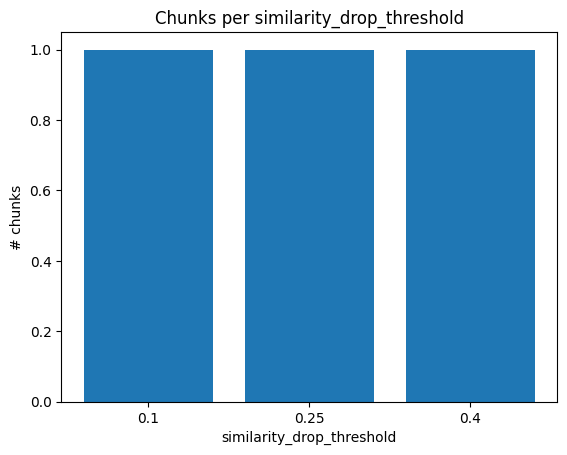

In [14]:
import re
import numpy as np
import matplotlib.pyplot as plt


def semantic_chunk_counts_for_thresholds(text, thresholds=(0.1, 0.25, 0.4), fallback_to_tfidf=True):
    """Compute chunk counts using sentence embeddings when available, else a local TF-IDF fallback."""
    clean = re.sub(r'\n+', ' ', text or '').strip()
    sentences = re.split(r'(?<=[.!?])\s+', clean)
    sentences = [s.strip() for s in sentences if s.strip()]

    if len(sentences) < 2:
        return {t: 1 for t in thresholds}

    try:
        from sentence_transformers import SentenceTransformer
        embedder = SentenceTransformer('all-MiniLM-L6-v2')
        embeddings = embedder.encode(sentences, normalize_embeddings=True)
        vectors = np.asarray(embeddings)
        mode = 'sentence-transformers'
    except Exception as e:
        if not fallback_to_tfidf:
            raise
        print(f"Model download failed ({e}). Falling back to TF-IDF similarity.")
        from sklearn.feature_extraction.text import TfidfVectorizer
        vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
        X = vectorizer.fit_transform(sentences)
        vectors = X.toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        vectors = vectors / norms
        mode = 'tf-idf'

    sims = []
    for i in range(len(vectors) - 1):
        a = np.asarray(vectors[i], dtype=float)
        b = np.asarray(vectors[i + 1], dtype=float)
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        sim = float(np.dot(a, b) / denom) if denom else 1.0
        sims.append(sim)

    counts = {}
    for t in thresholds:
        chunks = []
        current = [sentences[0]]
        for i, sim in enumerate(sims):
            if sim < (1.0 - t):
                chunks.append(' '.join(current))
                current = [sentences[i + 1]]
            else:
                current.append(sentences[i + 1])
        chunks.append(' '.join(current))
        counts[t] = len(chunks)

    print(f"Semantic chunking using: {mode}")
    return counts


try:
    text = sample_document
except NameError:
    text = ''

counts = semantic_chunk_counts_for_thresholds(text)
print('Threshold -> #chunks')
for k, v in counts.items():
    print(k, '->', v)

plt.bar([str(k) for k in counts.keys()], counts.values())
plt.title('Chunks per similarity_drop_threshold')
plt.xlabel('similarity_drop_threshold')
plt.ylabel('# chunks')
plt.show()